# SegFormer Proof-of-Concept Experiment for ADAS Perception

This notebook downloads multiple road-scene images automatically and runs **SegFormer** on all of them.


## 1. Install Dependencies

In [1]:
!pip install -q transformers torch torchvision pillow matplotlib requests


## 2. Download Multiple Example Images Automatically

In [2]:
import requests
from pathlib import Path

image_urls = [
    "https://plus.unsplash.com/premium_photo-1733263230987-de816feabf26?q=80&w=2070&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",  # Chicago street
    "https://images.unsplash.com/photo-1701518043851-4dab3207f78b?q=80&w=1035&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",  # highway sign car
    "https://images.unsplash.com/photo-1579653384681-c3ba17c4a8c9?q=80&w=862&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",  # city buildings road
    "https://images.unsplash.com/photo-1614685862822-f8fa20f87175?q=80&w=3132&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"   # pedestrians crossing
]

input_dir = Path("real_inputs")
input_dir.mkdir(exist_ok=True)

for i, url in enumerate(image_urls, start=1):
    img_path = input_dir / f"image_{i}.jpg"
    if not img_path.exists():
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        with open(img_path, "wb") as f:
            f.write(response.content)

print("Downloaded images:")
for f in sorted(input_dir.iterdir()):
    print("-", f.name)


Downloaded images:
- image_1.jpg
- image_2.jpg
- image_3.jpg
- image_4.jpg


## 3. Load SegFormer

In [3]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
model = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
id2label = model.config.id2label
print("Model loaded.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Model loaded.


## 4. Run Segmentation on All Images

In [4]:
target_class_names = {
    "person": [220, 20, 60],
    "car": [0, 114, 189],
    "road": [128, 64, 128],
    "sidewalk": [244, 35, 232],
    "building": [120, 120, 120],
}

target_ids = {}
for idx, label in id2label.items():
    label_lower = label.lower()
    if label_lower in target_class_names:
        target_ids[idx] = target_class_names[label_lower]

print("Matched classes:")
for idx, color in target_ids.items():
    print(idx, id2label[idx], color)

output_dir = Path("segformer_outputs")
output_dir.mkdir(exist_ok=True)

input_files = sorted(Path("real_inputs").glob("*"))
saved_files = []

for image_file in input_files:
    image = Image.open(image_file).convert("RGB")
    image_np = np.array(image)

    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)

    pred_seg = processor.post_process_semantic_segmentation(
        outputs,
        target_sizes=[image.size[::-1]]
    )[0]

    seg_np = pred_seg.cpu().numpy()
    color_mask = np.zeros_like(image_np, dtype=np.uint8)

    for class_id, color in target_ids.items():
        color_mask[seg_np == class_id] = color

    alpha = 0.45
    overlay = image_np.copy()
    mask_pixels = np.any(color_mask != 0, axis=-1)
    overlay[mask_pixels] = (
        image_np[mask_pixels] * (1 - alpha) + color_mask[mask_pixels] * alpha
    ).astype(np.uint8)

    out_path = output_dir / f"{image_file.stem}_overlay.png"
    Image.fromarray(overlay).save(out_path)
    saved_files.append(out_path)

print("Saved outputs:")
for f in saved_files:
    print("-", f.name)


Matched classes:
1 building [120, 120, 120]
6 road [128, 64, 128]
11 sidewalk [244, 35, 232]
12 person [220, 20, 60]
20 car [0, 114, 189]
Saved outputs:
- image_1_overlay.png
- image_2_overlay.png
- image_3_overlay.png
- image_4_overlay.png


## 5. Display the Segmentation Outputs

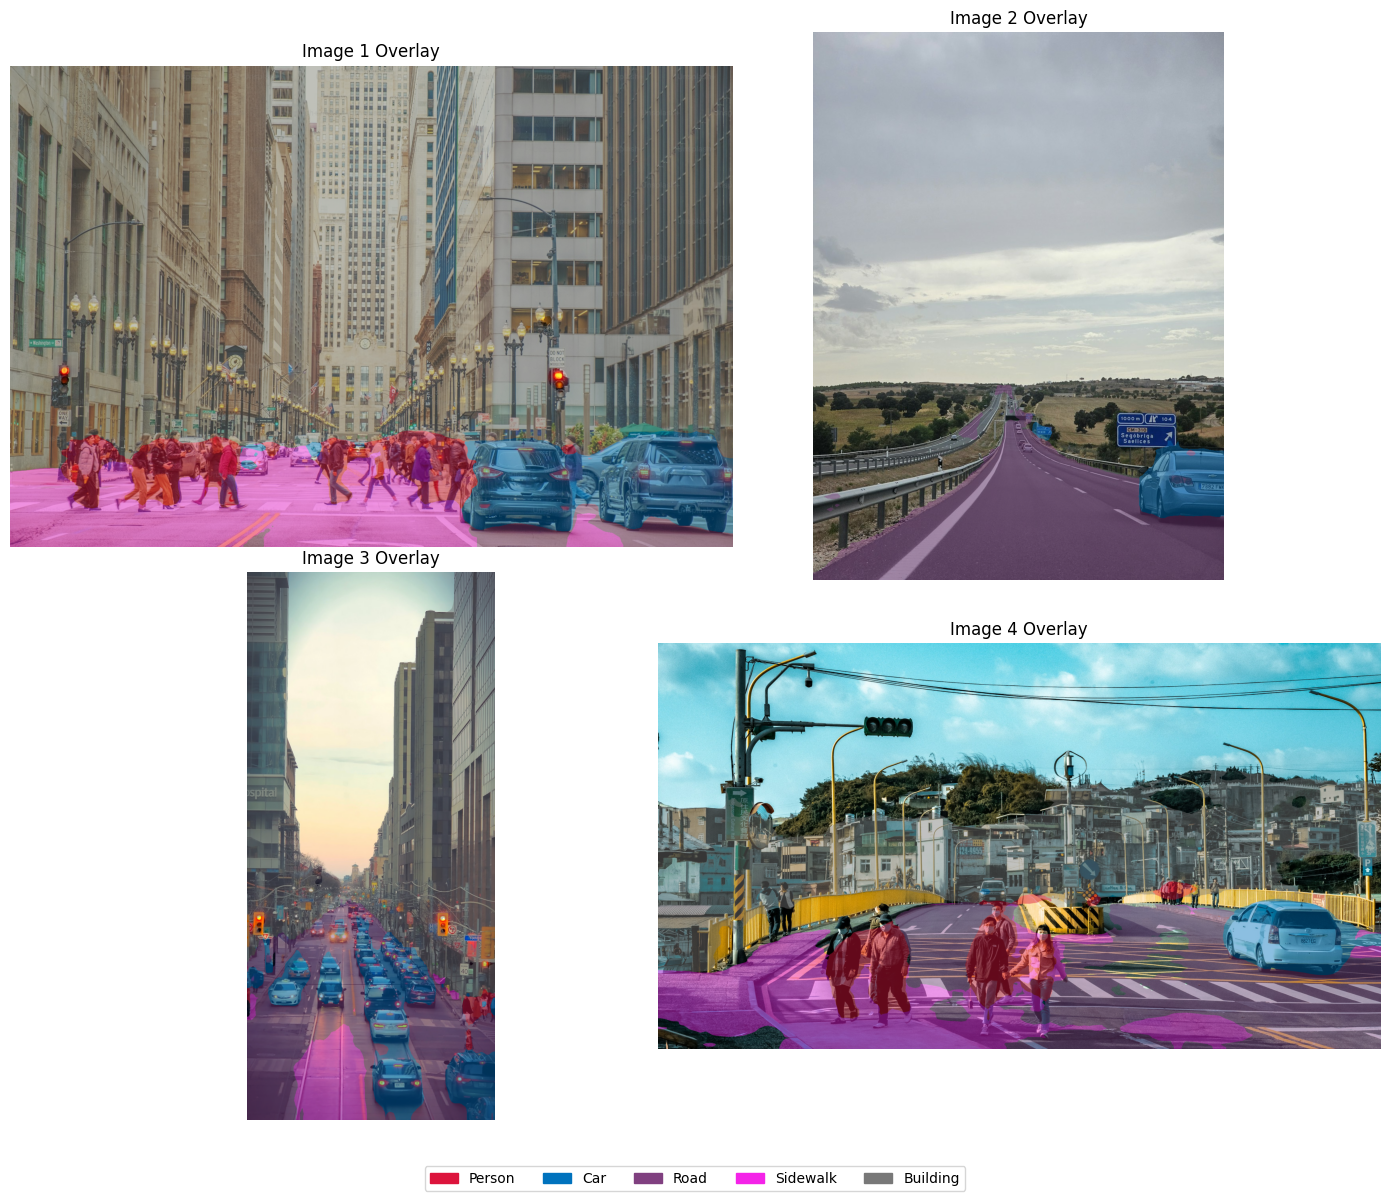

In [5]:
plt.figure(figsize=(14, 12))
for i, f in enumerate(saved_files, 1):
    plt.subplot(2, 2, i)
    plt.imshow(Image.open(f))
    plt.title(f.stem.replace("_", " ").title())
    plt.axis("off")

legend_handles = [
    mpatches.Patch(color=np.array(color) / 255.0, label=label.title())
    for label, color in target_class_names.items()
]
plt.figlegend(handles=legend_handles, loc="lower center", ncol=5, frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


## 6. Download the Segmentation Outputs

In [6]:
from google.colab import files

for f in saved_files:
    files.download(str(f))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes for the Report

- This notebook runs SegFormer on **multiple real-world road scenes**.
- The images are downloaded automatically, so there is no need to upload them manually.
